# Chapter 17. 하이브리드 아키텍처 설계 패턴

**Quantum AI: 핸즈온 양자머신러닝 with PennyLane — Part 3**

## 학습 목표
- Pre-net + Quantum + Post-net 패턴을 직접 구현
- 차원 매칭(고차원 입력 → 작은 큐비트 수)의 설계 방법
- 순수 고전 모델과 하이브리드 모델의 성능 비교

In [1]:
import pennylane as qml
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(0)

## 17.1 고차원 데이터 준비
10차원 합성 분류 데이터를 만든다.

In [2]:
X, y = make_classification(
    n_samples=300, n_features=10, n_informative=6,
    n_redundant=2, n_classes=2, random_state=0,
)
X = StandardScaler().fit_transform(X)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0)

X_tr = torch.tensor(X_tr, dtype=torch.float32)
X_te = torch.tensor(X_te, dtype=torch.float32)
y_tr = torch.tensor(y_tr, dtype=torch.long)
y_te = torch.tensor(y_te, dtype=torch.long)
print(f'학습: {X_tr.shape}, 테스트: {X_te.shape}')

학습: torch.Size([210, 10]), 테스트: torch.Size([90, 10])


## 17.2 하이브리드 모델 정의
10차원 → (Pre-net, Linear) → 4차원 → (Quantum, 4큐비트) → 4차원 → (Post-net, Linear) → 2 logits

In [3]:
n_qubits = 4
dev = qml.device('default.qubit', wires=n_qubits)

@qml.qnode(dev, interface='torch')
def qcircuit(inputs, weights):
    qml.AngleEmbedding(
        inputs, 
        wires=range(n_qubits), 
        rotation='Y'
    )
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shape = qml.StronglyEntanglingLayers.shape(
    n_layers=2, 
    n_wires=n_qubits
)
qlayer = qml.qnn.TorchLayer(qcircuit, {'weights': weight_shape})

class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Pre-net: 10 → 4
        self.pre = nn.Sequential(nn.Linear(10, 4), nn.Tanh())
        # Quantum layer
        self.qlayer = qlayer
        # Post-net: 4 → 2
        self.post = nn.Linear(n_qubits, 2)

    def forward(self, x):
        x = self.pre(x)
        x = self.qlayer(x)
        return self.post(x)

hybrid = HybridModel()
print(hybrid)
print(f'총 파라미터 수: {sum(p.numel() for p in hybrid.parameters())}')

HybridModel(
  (pre): Sequential(
    (0): Linear(in_features=10, out_features=4, bias=True)
    (1): Tanh()
  )
  (qlayer): <Quantum Torch Layer: func=qcircuit>
  (post): Linear(in_features=4, out_features=2, bias=True)
)
총 파라미터 수: 78


## 17.3 비교용 고전 모델 (같은 구조, 양자 부분만 MLP로)

In [4]:
class ClassicalModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(10, 4), nn.Tanh(),
            nn.Linear(4, 4), nn.Tanh(),  # 양자 layer 자리
            nn.Linear(4, 2),
        )
    def forward(self, x):
        return self.net(x)

classical = ClassicalModel()
print(f'고전 모델 파라미터 수: {sum(p.numel() for p in classical.parameters())}')

고전 모델 파라미터 수: 74


## 17.4 학습 함수와 비교

In [5]:
def train(model, X_tr, y_tr, X_te, y_te, epochs=40, lr=0.05):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    history = {'loss': [], 'test_acc': []}
    for ep in range(epochs):
        opt.zero_grad()
        loss = crit(model(X_tr), y_tr)
        loss.backward()
        opt.step()
        with torch.no_grad():
            acc = (model(X_te).argmax(1) == y_te).float().mean().item()
        history['loss'].append(loss.item())
        history['test_acc'].append(acc)
    return history

print('고전 모델 학습 중...')
h_cls = train(classical, X_tr, y_tr, X_te, y_te)
print('하이브리드 모델 학습 중...')
h_hyb = train(hybrid, X_tr, y_tr, X_te, y_te)
print('완료')

고전 모델 학습 중...
하이브리드 모델 학습 중...
완료


하이브리드 모델 학습 중...


완료


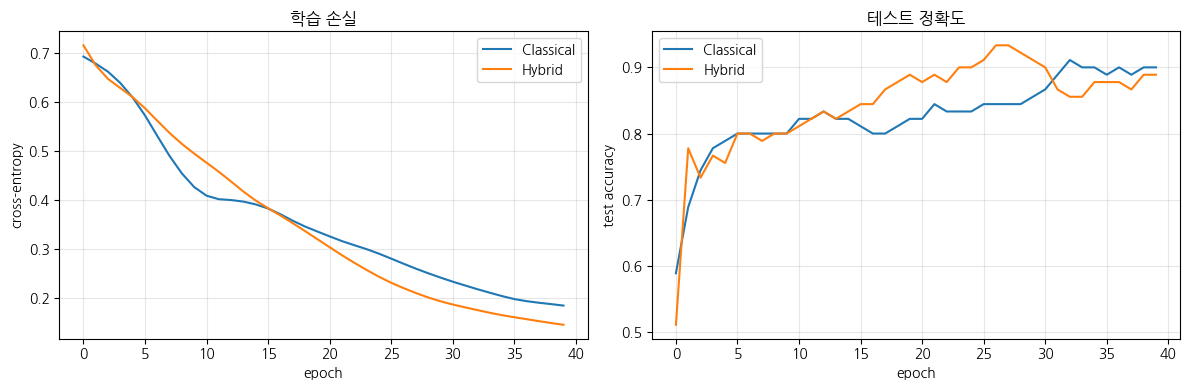

Classical 최종 정확도: 0.900
Hybrid    최종 정확도: 0.889


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h_cls['loss'], label='Classical')
axes[0].plot(h_hyb['loss'], label='Hybrid')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('cross-entropy')
axes[0].set_title('학습 손실'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(h_cls['test_acc'], label='Classical')
axes[1].plot(h_hyb['test_acc'], label='Hybrid')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('test accuracy')
axes[1].set_title('테스트 정확도'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Classical 최종 정확도: {h_cls["test_acc"][-1]:.3f}')
print(f'Hybrid    최종 정확도: {h_hyb["test_acc"][-1]:.3f}')

## 17.5 정리
- 하이브리드 모델 = Pre-net (차원 축소) + Quantum (4-10 큐비트) + Post-net (분류)
- `nn.Module` 서브클래스로 쉽게 구성
- 표준 PyTorch 옵티마이저와 손실 함수가 그대로 작동